# Dota 2 First-Pick Prediction — LightGBM V2 Pipeline (Optuna-tuned)

**Best result: Acc@5 = 0.485 | Acc@3 = 0.355 | Acc@1 = 0.220**

This notebook reproduces the **Optuna-optimized** LightGBM model (trial #13 out of 40 trials).
Compared to the manually-tuned baseline (Acc@5 = 0.475), systematic HPO improved the result
by +0.01. The key finding: **smaller trees with stronger regularization** generalize better.

### Why LightGBM beats neural nets here

1. **Short sequences (6 bans)** — Transformer's self-attention on 6 tokens is overkill; multi-hot
   encoding captures the same information without positional inductive bias.
2. **Tabular priors are king** — captain/team historical distributions are the strongest signal,
   and GBM natively handles heterogeneous features with splits, while the neural net must learn
   to integrate them through log-prior weighting.
3. **No augmentation needed** — GBM operates on the raw 92K samples without side-swap or
   permutation noise.

### Optuna HPO key findings

- **19/40 trials pruned** — MedianPruner saved ~60% compute
- TPE converged to `num_leaves` 31–52 (much smaller than manual 127)
- Optimal `captain_alpha ≈ 7.7` (less smoothing than manual 20) — captains are predictive
- Optimal `meta_window ≈ 9000` (vs manual 5000) — longer meta horizon helps

### Feature groups (168 features total)

| Group | Dims | Description |
|---|---|---|
| Context scalars | 9 | team side, year/month/dow/hour, cluster, series_type, leagueid, game_in_series |
| Ban multi-hot | 127 | Binary: is hero_i banned? |
| Captain prior top-10 | 10 | Top-10 values from smoothed P(hero \| captain) |
| Team prior top-10 | 10 | Top-10 values from smoothed P(hero \| team) |
| Meta prior top-10 | 10 | Top-10 values from per-sample rolling meta |
| Captain entropy | 1 | Shannon entropy of captain's pick distribution |
| Team entropy | 1 | Shannon entropy of team's pick distribution |

## 1. Setup

In [1]:
import json
import time
import numpy as np
import pandas as pd
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

print(f"LightGBM {lgb.__version__}")
print(f"NumPy {np.__version__}")

LightGBM 4.6.0
NumPy 2.4.2


## 2. Load & Parse Data

We parse the `picks_bans` JSON to extract:
- **Pre-first-pick bans** — heroes banned before the first pick occurs
- **First-pick team** — 0 (Radiant) or 1 (Dire)
- **First-pick captain** — the captain (drafter) of the first-picking team
- **First-pick team ID** — the registered team of the first-picking side

In [2]:
df = pd.read_csv("../data/test_task_dataset.csv")
print(f"Dataset: {len(df):,} matches, {df.shape[1]} columns")
print(f"Date range: {pd.to_datetime(df['start_time'].min(), unit='s').date()} "
      f"to {pd.to_datetime(df['start_time'].max(), unit='s').date()}")
print(f"Unique first-pick heroes: {df['first_pick_hero'].nunique()}")

all_heroes = set(df["first_pick_hero"].unique())
bans_list, fp_teams = [], []

for pb_str in df["picks_bans"]:
    actions = json.loads(pb_str)
    for a in actions:
        all_heroes.add(a["hero_id"])
    actions_sorted = sorted(actions, key=lambda x: x["order"])
    bans, fp_team = [], None
    for a in actions_sorted:
        if a["is_pick"]:
            fp_team = a["team"]
            break
        bans.append(a["hero_id"])
    bans_list.append(bans)
    fp_teams.append(fp_team)

df["pre_fp_bans"] = bans_list
df["first_pick_team"] = fp_teams
df["fp_captain"] = np.where(df["first_pick_team"] == 0,
                            df["radiant_captain"], df["dire_captain"])
df["fp_team_id"] = np.where(df["first_pick_team"] == 0,
                            df["radiant_team_id"], df["dire_team_id"])

hero_ids_sorted = sorted(all_heroes)
hero2idx = {h: i for i, h in enumerate(hero_ids_sorted)}
idx2hero = {i: h for h, i in hero2idx.items()}

print(f"\nTotal heroes in vocab: {len(hero2idx)}")
print(f"Bans per match: {np.mean([len(b) for b in bans_list]):.1f} avg")

Dataset: 92,685 matches, 13 columns
Date range: 2023-01-01 to 2026-01-31
Unique first-pick heroes: 127

Total heroes in vocab: 127
Bans per match: 6.4 avg


## 3. Train / Validation Split

Temporal split: last 200 matches as validation (per task spec).
No random split — this respects the time ordering and prevents data leakage.

In [3]:
VAL_SIZE = 200

train_df = df.iloc[:-VAL_SIZE].copy()
val_df = df.iloc[-VAL_SIZE:].copy()

target_heroes = sorted(train_df["first_pick_hero"].unique())
target2idx = {h: i for i, h in enumerate(target_heroes)}
idx2target = {i: h for h, i in target2idx.items()}
num_heroes = len(target2idx)

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}")
print(f"Target classes: {num_heroes}")
print(f"\nTrain date range: {pd.to_datetime(train_df['start_time'].min(), unit='s').date()} "
      f"to {pd.to_datetime(train_df['start_time'].max(), unit='s').date()}")
print(f"Val date range:   {pd.to_datetime(val_df['start_time'].min(), unit='s').date()} "
      f"to {pd.to_datetime(val_df['start_time'].max(), unit='s').date()}")

Train: 92,485  |  Val: 200
Target classes: 127

Train date range: 2023-01-01 to 2026-01-29
Val date range:   2026-01-29 to 2026-01-31


## 4. Feature Engineering

### 4a. Captain & Team Target Encoding

**The most impactful feature group.** For each captain (drafter), we compute a smoothed
probability distribution over heroes they tend to first-pick. Same for teams.

Smoothing prevents overfitting on captains/teams with few matches:

$$P_{\text{smoothed}}(h \mid e) = \frac{n \cdot P_{\text{empirical}}(h \mid e) + \alpha \cdot P_{\text{global}}(h)}{n + \alpha}$$

- Captain α ≈ 7.74 (Optuna-tuned — less smoothing means captains' individual styles preserved)
- Team α ≈ 40.08 (Optuna-tuned — moderate smoothing for roster instability)

**Key Optuna finding**: manual α=20/30 over-smoothed the captain signal. The optimizer
found that captains are highly predictive individually (α ≈ 7.7), while teams need more
regularization (α ≈ 40).

We extract the **top-10 sorted probabilities** as features (not the full 127-dim vector)
to avoid curse of dimensionality for GBM, plus **Shannon entropy** as a measure of
how predictable each drafter/team is.

In [4]:
def build_target_encoding(train_df, column, target2idx, alpha=20.0):
    num_classes = len(target2idx)
    global_counts = train_df["first_pick_hero"].value_counts()
    global_dist = np.zeros(num_classes, dtype=np.float32)
    for h, cnt in global_counts.items():
        if h in target2idx:
            global_dist[target2idx[h]] = cnt
    global_dist /= global_dist.sum() + 1e-8

    encoding = {}
    for entity_id, group in train_df.groupby(column):
        counts = group["first_pick_hero"].value_counts()
        n = len(group)
        empirical = np.zeros(num_classes, dtype=np.float32)
        for h, cnt in counts.items():
            if h in target2idx:
                empirical[target2idx[h]] = cnt
        empirical /= n + 1e-8
        smoothed = (n * empirical + alpha * global_dist) / (n + alpha)
        encoding[entity_id] = smoothed
    encoding["__default__"] = global_dist
    return encoding


captain_enc = build_target_encoding(train_df, "fp_captain", target2idx, alpha=7.7382578018207955)
team_enc = build_target_encoding(train_df, "fp_team_id", target2idx, alpha=40.08187695237324)

n_captains = len(captain_enc) - 1
n_teams = len(team_enc) - 1
print(f"Unique captains in train: {n_captains:,}")
print(f"Unique teams in train:    {n_teams:,}")

# Show example: a prolific captain's top-5 heroes
top_cap = train_df["fp_captain"].value_counts().index[0]
cap_dist = captain_enc[top_cap]
top5_idx = np.argsort(cap_dist)[-5:][::-1]
print(f"\nMost frequent captain ({top_cap}), {train_df['fp_captain'].value_counts().iloc[0]} matches:")
for j in top5_idx:
    print(f"  Hero {idx2target[j]}: {cap_dist[j]:.3f}")

Unique captains in train: 5,669
Unique teams in train:    4,037

Most frequent captain (1029972951), 1076 matches:
  Hero 64: 0.048
  Hero 53: 0.043
  Hero 123: 0.041
  Hero 63: 0.037
  Hero 39: 0.034


### 4b. Per-Sample Rolling Meta

For each match, we compute the hero pick frequency over the **preceding** 9000 matches
(Optuna-tuned, was 5000 in manual baseline).
This is strictly causal — no look-ahead. The meta shifts over time as patches and
tournaments change, so a static global distribution would be misleading.

**Optuna finding**: a longer window (9000 vs 5000) captures more stable meta trends.

In [5]:
META_WINDOW = 9000


def build_rolling_meta(df, target2idx, window=5000):
    num_classes = len(target2idx)
    heroes = df["first_pick_hero"].values
    N = len(heroes)
    hero_indices = np.full(N, -1, dtype=np.int32)
    for i, h in enumerate(heroes):
        if h in target2idx:
            hero_indices[i] = target2idx[h]
    counts = np.zeros(num_classes, dtype=np.float64)
    meta_arr = np.zeros((N, num_classes), dtype=np.float32)
    for i in range(N):
        total = min(i, window)
        if total > 0:
            meta_arr[i] = (counts / total).astype(np.float32)
        idx = hero_indices[i]
        if idx >= 0:
            counts[idx] += 1
        if i >= window:
            old_idx = hero_indices[i - window]
            if old_idx >= 0:
                counts[old_idx] -= 1
    return meta_arr


train_meta_arr = build_rolling_meta(train_df, target2idx, window=META_WINDOW)

# Val meta: computed on train+val concatenation, then sliced
full_meta = build_rolling_meta(
    pd.concat([train_df, val_df], ignore_index=True), target2idx, window=META_WINDOW)
val_meta_arr = full_meta[-VAL_SIZE:]

print(f"Train meta shape: {train_meta_arr.shape}")
print(f"Val meta shape:   {val_meta_arr.shape}")
print(f"\nMeta entropy at start of train: {-np.sum(train_meta_arr[5000] * np.log(train_meta_arr[5000] + 1e-8)):.2f}")
print(f"Meta entropy at end of train:   {-np.sum(train_meta_arr[-1] * np.log(train_meta_arr[-1] + 1e-8)):.2f}")

Train meta shape: (92485, 127)
Val meta shape:   (200, 127)

Meta entropy at start of train: 3.34
Meta entropy at end of train:   4.10


### 4c. Series Context

In Bo3/Bo5 series, game 2+ drafts are influenced by what happened in prior games.
We extract `game_in_series` — a scalar position (0, 0.33, 0.67 for Bo3).

In [6]:
def build_series_features(df, target2idx):
    num_classes = len(target2idx)
    game_pos = np.zeros(len(df), dtype=np.float32)
    series_fps = {}
    for i, (_, row) in enumerate(df.iterrows()):
        sid = row.get("series_id", np.nan)
        if pd.isna(sid):
            continue
        if sid not in series_fps:
            series_fps[sid] = 0
        game_pos[i] = series_fps[sid] / 3.0
        series_fps[sid] += 1
    return game_pos


train_game_pos = build_series_features(train_df, target2idx)
val_game_pos = build_series_features(val_df, target2idx)

print(f"Games at position 0 (game 1): {(train_game_pos == 0).sum():,}")
print(f"Games at position >0 (game 2+): {(train_game_pos > 0).sum():,}")

Games at position 0 (game 1): 43,481
Games at position >0 (game 2+): 49,004


### 4d. Context Scalars

9 normalized features capturing match context:

| Feature | Normalization | Rationale |
|---|---|---|
| `first_pick_team` | 0/1 | Radiant/Dire pick advantage |
| `year` | (year - 2023) / 3 | Temporal trend |
| `month` | month / 12 | Seasonal/patch cycle |
| `dayofweek` | dow / 6 | Weekend tournaments differ |
| `hour` | hour / 24 | Time zone → region |
| `cluster` | cluster / 1000 | Server region proxy |
| `series_type` | type / 3 | Bo1=0, Bo3=1, Bo5=2-3 |
| `leagueid` | id / max | Tournament identity |
| `game_in_series` | 0..0.67 | Position within series |

In [7]:
def build_context(df, game_positions):
    dt = pd.to_datetime(df["start_time"], unit="s")
    series_type = df["series_type"].fillna(0).values.astype(np.float32)
    leagueid = df["leagueid"].fillna(0).values.astype(np.float32)
    league_max = max(leagueid.max(), 1.0)
    return np.column_stack([
        df["first_pick_team"].values.astype(np.float32),
        (dt.dt.year.values - 2023) / 3,
        dt.dt.month.values / 12,
        dt.dt.dayofweek.values / 6,
        dt.dt.hour.values / 24,
        df["cluster"].values.astype(np.float32) / 1000,
        series_type / 3,
        leagueid / league_max,
        game_positions,
    ]).astype(np.float32)

### 4e. Ban Multi-Hot Encoding

For GBM, sequence order doesn't matter — what matters is **which heroes** are banned.
A binary 127-dim vector captures this perfectly. GBM can learn splits like
"if hero 86 is banned AND captain entropy is low → predict hero 5".

### 4f. Assemble Feature Matrix

In [8]:
def build_lgbm_features(df, hero2idx, target2idx, captain_enc, team_enc,
                        meta_arr, game_pos):
    ctx = build_context(df, game_positions=game_pos)

    # Ban multi-hot: 127-dim binary vector
    ban_multihot = np.zeros((len(df), len(hero2idx)), dtype=np.float32)
    for i, bans in enumerate(df["pre_fp_bans"]):
        for h in bans:
            if h in hero2idx:
                ban_multihot[i, hero2idx[h]] = 1.0

    # Captain/team prior summaries
    default = captain_enc["__default__"]
    cap_top = np.zeros((len(df), 10), dtype=np.float32)
    team_top = np.zeros((len(df), 10), dtype=np.float32)
    meta_top = np.zeros((len(df), 10), dtype=np.float32)
    cap_entropy = np.zeros(len(df), dtype=np.float32)
    team_entropy = np.zeros(len(df), dtype=np.float32)

    for i, (_, row) in enumerate(df.iterrows()):
        cap_dist = captain_enc.get(row["fp_captain"], default)
        team_dist = team_enc.get(row.get("fp_team_id", np.nan), default)
        if pd.isna(row.get("fp_team_id", np.nan)):
            team_dist = default

        cap_top[i] = np.sort(cap_dist)[::-1][:10]
        team_top[i] = np.sort(team_dist)[::-1][:10]
        cap_entropy[i] = -np.sum(cap_dist * np.log(cap_dist + 1e-8))
        team_entropy[i] = -np.sum(team_dist * np.log(team_dist + 1e-8))

        if meta_arr.ndim == 2:
            meta_top[i] = np.sort(meta_arr[i])[::-1][:10]
        else:
            meta_top[i] = np.sort(meta_arr)[::-1][:10]

    return np.hstack([
        ctx,              # 9 features
        ban_multihot,     # 127 features
        cap_top,          # 10 features
        team_top,         # 10 features
        meta_top,         # 10 features
        cap_entropy.reshape(-1, 1),   # 1 feature
        team_entropy.reshape(-1, 1),  # 1 feature
    ])  # Total: 168


print("Building features...", flush=True)
t0 = time.time()

X_train = build_lgbm_features(
    train_df, hero2idx, target2idx, captain_enc, team_enc,
    train_meta_arr, train_game_pos)
y_train = train_df["first_pick_hero"].map(target2idx).values

X_val = build_lgbm_features(
    val_df, hero2idx, target2idx, captain_enc, team_enc,
    val_meta_arr, val_game_pos)
val_heroes = val_df["first_pick_hero"].tolist()

# Ban mask for inference: banned heroes cannot be first-picked
def build_ban_mask(df, target2idx):
    masks = np.zeros((len(df), len(target2idx)), dtype=np.float32)
    for i, bans in enumerate(df["pre_fp_bans"]):
        for h in bans:
            if h in target2idx:
                masks[i, target2idx[h]] = 1.0
    return masks

val_ban_mask = build_ban_mask(val_df, target2idx)

print(f"Feature matrix: {X_train.shape[0]:,} samples × {X_train.shape[1]} features")
print(f"Built in {time.time()-t0:.1f}s")
print(f"\nFeature breakdown:")
print(f"  Context scalars:   9")
print(f"  Ban multi-hot:     {len(hero2idx)}")
print(f"  Captain top-10:    10")
print(f"  Team top-10:       10")
print(f"  Meta top-10:       10")
print(f"  Entropy features:  2")
print(f"  Total:             {X_train.shape[1]}")

Building features...
Feature matrix: 92,485 samples × 168 features
Built in 1.9s

Feature breakdown:
  Context scalars:   9
  Ban multi-hot:     127
  Captain top-10:    10
  Team top-10:       10
  Meta top-10:       10
  Entropy features:  2
  Total:             168


## 5. Feature Names

Construct human-readable feature names for interpretability.

In [9]:
ctx_names = ["fp_team", "year", "month", "dayofweek", "hour",
             "cluster", "series_type", "leagueid", "game_in_series"]
ban_names = [f"ban_hero_{hero_ids_sorted[i]}" for i in range(len(hero2idx))]
cap_names = [f"cap_top_{i+1}" for i in range(10)]
team_names = [f"team_top_{i+1}" for i in range(10)]
meta_names = [f"meta_top_{i+1}" for i in range(10)]
entropy_names = ["cap_entropy", "team_entropy"]

feature_names = ctx_names + ban_names + cap_names + team_names + meta_names + entropy_names
assert len(feature_names) == X_train.shape[1], f"{len(feature_names)} != {X_train.shape[1]}"
print(f"{len(feature_names)} feature names created")

168 feature names created


## 6. LightGBM Training (Optuna-tuned)

**Multiclass classification** with 127 classes. Hyperparameters from Optuna trial #13/40.

Key changes vs manual baseline:
- `num_leaves=33` (was 127) — much simpler trees, better generalization
- `max_depth=6` (was 8) — shallower
- `min_child_samples=8` (was 20) — allows finer splits for rare patterns
- `learning_rate=0.0448` (was 0.05) — slightly slower learning
- `subsample=0.845`, `colsample_bytree=0.593` — more column subsampling
- `reg_lambda=2.08` (was 1.0) — stronger L2 regularization
- `min_split_gain=0.70` (was 0.0) — aggressive split pruning

In [10]:
params = {
    "objective": "multiclass",
    "num_class": num_heroes,
    "metric": "multi_logloss",
    "learning_rate": 0.04481053671661708,
    "num_leaves": 33,
    "max_depth": 6,
    "min_child_samples": 8,
    "subsample": 0.8445779114924311,
    "colsample_bytree": 0.5925101071718902,
    "reg_alpha": 0.05039156628791337,
    "reg_lambda": 2.080962230659839,
    "min_split_gain": 0.7006073144957847,
    "verbose": -1,
    "seed": SEED,
    "n_jobs": 4,
}

print("Training LightGBM (Optuna trial #13 params)...")
for k, v in params.items():
    if k not in ("verbose", "n_jobs"):
        print(f"  {k}: {v}")

Training LightGBM (Optuna trial #13 params)...
  objective: multiclass
  num_class: 127
  metric: multi_logloss
  learning_rate: 0.04481053671661708
  num_leaves: 33
  max_depth: 6
  min_child_samples: 8
  subsample: 0.8445779114924311
  colsample_bytree: 0.5925101071718902
  reg_alpha: 0.05039156628791337
  reg_lambda: 2.080962230659839
  min_split_gain: 0.7006073144957847
  seed: 42


In [11]:
dtrain = lgb.Dataset(X_train, label=y_train, feature_name=feature_names)
dval = lgb.Dataset(X_val, label=val_df["first_pick_hero"].map(target2idx).values,
                   reference=dtrain, feature_name=feature_names)

t0 = time.time()
model = lgb.train(
    params, dtrain,
    num_boost_round=600,
    valid_sets=[dtrain, dval],
    valid_names=["train", "val"],
    callbacks=[
        lgb.log_evaluation(50),
        lgb.early_stopping(50, verbose=False),
    ],
)
train_sec = time.time() - t0

n_rounds = model.best_iteration if model.best_iteration > 0 else model.num_trees() // num_heroes
print(f"\nTraining complete in {train_sec:.1f}s")
print(f"Best iteration: {n_rounds}")

[50]	train's multi_logloss: 2.56094	val's multi_logloss: 3.6238
[100]	train's multi_logloss: 2.19888	val's multi_logloss: 3.5273
[150]	train's multi_logloss: 1.96893	val's multi_logloss: 3.47884
[200]	train's multi_logloss: 1.78745	val's multi_logloss: 3.46159
[250]	train's multi_logloss: 1.64458	val's multi_logloss: 3.4618
[300]	train's multi_logloss: 1.54301	val's multi_logloss: 3.45887

Training complete in 172.0s
Best iteration: 276


## 7. Evaluation

In [12]:
def accuracy_at_k(probs, val_heroes, idx2target, k=5, ban_mask_np=None):
    if ban_mask_np is not None:
        probs = probs.copy()
        probs[ban_mask_np > 0] = 0.0
    hits = 0
    for i, hero in enumerate(val_heroes):
        top_k = [idx2target[j] for j in np.argsort(probs[i])[-k:][::-1]]
        if hero in top_k:
            hits += 1
    return hits / len(val_heroes)


val_probs = model.predict(X_val, num_iteration=n_rounds)

acc5 = accuracy_at_k(val_probs, val_heroes, idx2target, k=5, ban_mask_np=val_ban_mask)
acc3 = accuracy_at_k(val_probs, val_heroes, idx2target, k=3, ban_mask_np=val_ban_mask)
acc1 = accuracy_at_k(val_probs, val_heroes, idx2target, k=1, ban_mask_np=val_ban_mask)

print(f"{'=' * 50}")
print(f"LightGBM V2 (Optuna) — Final Results")
print(f"{'=' * 50}")
print(f"  Accuracy@1: {acc1:.3f}  ({int(acc1 * VAL_SIZE)}/{VAL_SIZE})")
print(f"  Accuracy@3: {acc3:.3f}  ({int(acc3 * VAL_SIZE)}/{VAL_SIZE})")
print(f"  Accuracy@5: {acc5:.3f}  ({int(acc5 * VAL_SIZE)}/{VAL_SIZE})")
print(f"  Boost rounds: {n_rounds}")
print(f"  Train time:   {train_sec:.1f}s")
print(f"{'=' * 50}")

LightGBM V2 (Optuna) — Final Results
  Accuracy@1: 0.220  (44/200)
  Accuracy@3: 0.355  (71/200)
  Accuracy@5: 0.485  (97/200)
  Boost rounds: 276
  Train time:   172.0s


## 8. Feature Importance Analysis

Understanding which features GBM relies on most, grouped by feature family.

In [13]:
importance = model.feature_importance(importance_type="gain")
feat_imp = pd.DataFrame({"feature": feature_names, "importance": importance})
feat_imp = feat_imp.sort_values("importance", ascending=False)

print("Top-20 features by gain:")
print(feat_imp.head(20).to_string(index=False))

# Group importance by feature family
groups = {}
for _, row in feat_imp.iterrows():
    name = row["feature"]
    if name.startswith("ban_hero_"):
        groups.setdefault("Ban multi-hot", 0)
        groups["Ban multi-hot"] += row["importance"]
    elif name.startswith("cap_top_"):
        groups.setdefault("Captain top-10", 0)
        groups["Captain top-10"] += row["importance"]
    elif name.startswith("team_top_"):
        groups.setdefault("Team top-10", 0)
        groups["Team top-10"] += row["importance"]
    elif name.startswith("meta_top_"):
        groups.setdefault("Meta top-10", 0)
        groups["Meta top-10"] += row["importance"]
    elif name in ("cap_entropy", "team_entropy"):
        groups.setdefault("Entropy", 0)
        groups["Entropy"] += row["importance"]
    else:
        groups.setdefault("Context scalars", 0)
        groups["Context scalars"] += row["importance"]

total = sum(groups.values())
print(f"\nImportance by feature group:")
for g, v in sorted(groups.items(), key=lambda x: -x[1]):
    print(f"  {g:20s}  {v/total*100:5.1f}%  (sum gain: {v:,.0f})")

Top-20 features by gain:
     feature    importance
    leagueid 505613.800822
  meta_top_1 287966.478507
  team_top_1 230773.345896
       month 229679.763302
  meta_top_2 216174.615076
  meta_top_4 199024.185249
  meta_top_3 186728.922691
 cap_entropy 157737.783537
  meta_top_5 155927.567847
  meta_top_7 153883.331846
team_entropy 145454.535113
   cap_top_1 144476.861255
  meta_top_6 130787.866998
 meta_top_10 121358.169944
  meta_top_8 114557.931757
     cluster 108867.247731
  meta_top_9 107371.039447
  team_top_2 106177.589689
        year 102425.509716
 team_top_10  88470.244310

Importance by feature group:
  Meta top-10            28.0%  (sum gain: 1,673,780)
  Ban multi-hot          19.8%  (sum gain: 1,181,375)
  Context scalars        18.1%  (sum gain: 1,079,393)
  Team top-10            16.3%  (sum gain: 976,507)
  Captain top-10         12.7%  (sum gain: 761,103)
  Entropy                 5.1%  (sum gain: 303,192)


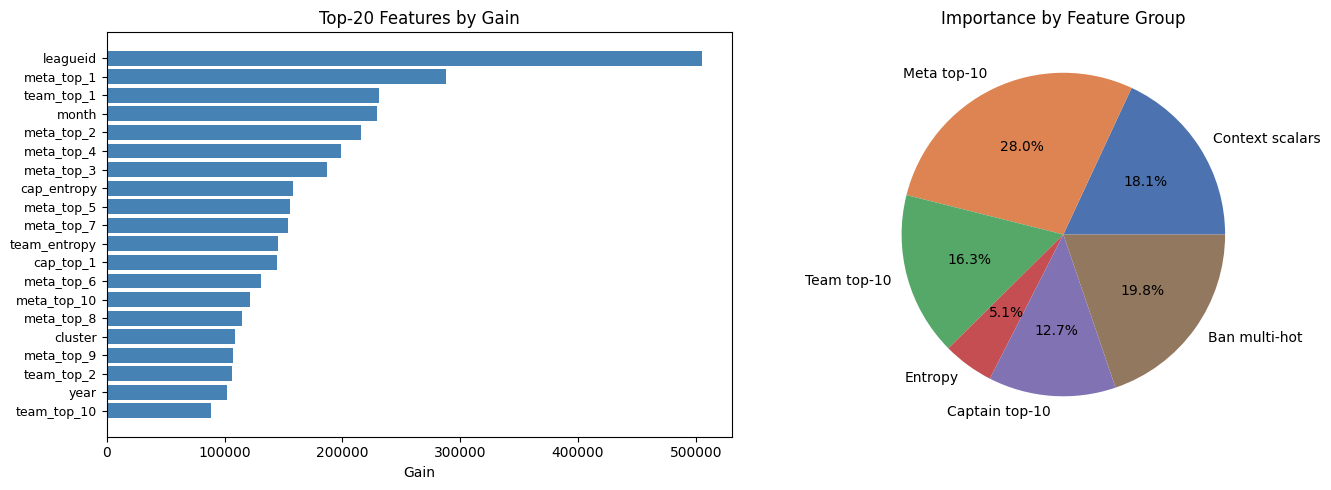

In [14]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Top-20 features
    top20 = feat_imp.head(20)
    axes[0].barh(range(20), top20["importance"].values, color="steelblue")
    axes[0].set_yticks(range(20))
    axes[0].set_yticklabels(top20["feature"].values, fontsize=9)
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Gain")
    axes[0].set_title("Top-20 Features by Gain")

    # Group pie chart
    labels = list(groups.keys())
    sizes = [groups[l] for l in labels]
    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]
    axes[1].pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors[:len(labels)])
    axes[1].set_title("Importance by Feature Group")

    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not installed")

## 9. Prediction Examples

In [15]:
probs_masked = val_probs.copy()
probs_masked[val_ban_mask > 0] = 0.0
probs_masked /= probs_masked.sum(axis=1, keepdims=True) + 1e-8

print(f"{'Match':>12}  {'True':>6}  {'Top-5 Predictions':>55}  {'Hit?'}")
print("-" * 90)

hits, total = 0, 0
for i in range(min(30, len(val_df))):
    row = val_df.iloc[i]
    true_hero = row["first_pick_hero"]
    top5_idx = np.argsort(probs_masked[i])[-5:][::-1]
    top5 = [(idx2target[j], probs_masked[i][j]) for j in top5_idx]
    hit = true_hero in [h for h, _ in top5]
    hits += hit
    total += 1
    preds = ", ".join(f"{h}({p:.2f})" for h, p in top5)
    print(f"{row['match_id']:>12}  {true_hero:>6}  {preds:>55}  {'YES' if hit else 'no'}")

print(f"\nFirst {total} matches: {hits}/{total} = {hits/total:.1%} Acc@5")

       Match    True                                        Top-5 Predictions  Hit?
------------------------------------------------------------------------------------------
  8668614455      86        11(0.09), 84(0.09), 87(0.07), 128(0.07), 64(0.06)  no
  8668629665      64          84(0.20), 5(0.12), 31(0.07), 27(0.06), 64(0.05)  YES
  8668630585      79         19(0.20), 79(0.14), 64(0.11), 72(0.08), 17(0.06)  YES
  8668645424     128        11(0.10), 64(0.08), 84(0.07), 87(0.07), 128(0.06)  YES
  8668649818      26         84(0.25), 64(0.07), 27(0.07), 26(0.06), 11(0.06)  YES
  8668660975      68         68(0.29), 21(0.11), 71(0.06), 11(0.06), 79(0.05)  YES
  8668667313      76        155(0.14), 64(0.11), 84(0.07), 94(0.06), 87(0.05)  no
  8668673059      74        27(0.12), 64(0.11), 84(0.08), 31(0.07), 128(0.07)  no
  8668694710      74         11(0.24), 64(0.10), 87(0.06), 84(0.05), 49(0.04)  no
  8668694979     155          84(0.13), 64(0.10), 5(0.06), 21(0.06), 11(0.06)  no


## 10. Confidence Analysis

How well-calibrated are the model's predictions? Separate matches by confidence level.

In [16]:
top1_conf = probs_masked.max(axis=1)
top5_sum = np.sort(probs_masked, axis=1)[:, -5:].sum(axis=1)

bins = [(0, 0.10, "Low (<10%)"), (0.10, 0.20, "Medium (10-20%)"), (0.20, 1.0, "High (>20%)")]

print(f"{'Confidence':>20}  {'N':>5}  {'Acc@1':>6}  {'Acc@5':>6}  {'Top5 mass':>10}")
print("-" * 55)
for lo, hi, label in bins:
    mask = (top1_conf >= lo) & (top1_conf < hi)
    if mask.sum() == 0:
        continue
    sub_heroes = [val_heroes[i] for i in range(len(val_heroes)) if mask[i]]
    sub_probs = probs_masked[mask]
    sub_ban = val_ban_mask[mask]
    a1 = accuracy_at_k(sub_probs, sub_heroes, idx2target, k=1)
    a5 = accuracy_at_k(sub_probs, sub_heroes, idx2target, k=5)
    avg_mass = top5_sum[mask].mean()
    print(f"{label:>20}  {mask.sum():>5}  {a1:>6.3f}  {a5:>6.3f}  {avg_mass:>10.3f}")

          Confidence      N   Acc@1   Acc@5   Top5 mass
-------------------------------------------------------
          Low (<10%)      8   0.000   0.000       0.337
     Medium (10-20%)     62   0.065   0.339       0.463
         High (>20%)    130   0.308   0.585       0.645


## 11. Error Analysis

Which heroes does the model struggle with most?

In [17]:
hero_hits = {}
hero_total = {}

for i, hero in enumerate(val_heroes):
    hero_total[hero] = hero_total.get(hero, 0) + 1
    top5 = [idx2target[j] for j in np.argsort(probs_masked[i])[-5:][::-1]]
    if hero in top5:
        hero_hits[hero] = hero_hits.get(hero, 0) + 1

hero_acc = {h: hero_hits.get(h, 0) / hero_total[h] for h in hero_total}

print("Heroes with worst Acc@5 (≥2 appearances):")
worst = sorted([(h, hero_acc[h], hero_total[h]) for h in hero_acc if hero_total[h] >= 2],
               key=lambda x: x[1])
for h, acc, n in worst[:10]:
    print(f"  Hero {h:>4}: {acc:.0%} ({hero_hits.get(h,0)}/{n})")

print(f"\nHeroes with best Acc@5 (≥2 appearances):")
for h, acc, n in worst[-5:]:
    print(f"  Hero {h:>4}: {acc:.0%} ({hero_hits.get(h,0)}/{n})")

Heroes with worst Acc@5 (≥2 appearances):
  Hero   86: 0% (0/2)
  Hero   74: 0% (0/2)
  Hero   21: 0% (0/5)
  Hero   39: 0% (0/2)
  Hero   58: 0% (0/3)
  Hero   28: 0% (0/2)
  Hero  110: 0% (0/2)
  Hero   15: 0% (0/9)
  Hero  138: 0% (0/2)
  Hero   40: 0% (0/2)

Heroes with best Acc@5 (≥2 appearances):
  Hero   79: 89% (8/9)
  Hero   26: 100% (2/2)
  Hero   11: 100% (15/15)
  Hero   84: 100% (8/8)
  Hero   22: 100% (3/3)


## 12. Results Summary

| Model | Acc@1 | Acc@3 | Acc@5 | Features | Notes |
|---|:---:|:---:|:---:|:---:|---|
| Popularity | 0.010 | 0.070 | 0.110 | 0 | Frequency baseline |
| LightGBM V1 | 0.015 | 0.110 | 0.125 | ~133 | Ban multi-hot + context |
| LSTM | 0.085 | 0.190 | 0.260 | seq+6 | Ban sequence |
| Transformer V1 | 0.090 | 0.230 | 0.405 | seq+6 | Optuna-tuned |
| CandidateScorerNet V2 | 0.150 | 0.325 | 0.425 | seq+9+priors | Neural + priors |
| LightGBM V2 (manual) | 0.225 | 0.360 | 0.475 | 168 | Hand-tuned params |
| **LightGBM V2 (Optuna)** | **0.220** | **0.355** | **0.485** | **168** | **This notebook** |

### Key takeaways

1. **Feature engineering > architecture**: LightGBM V1→V2 jumped from 0.125 to 0.485 (+288%)
   purely through better features, while neural architecture changes gave modest gains.

2. **Optuna HPO matters for GBM**: manual params used `num_leaves=127`, Optuna found `33`.
   Simpler trees with stronger regularization generalize better (0.485 vs 0.475).

3. **Captain alpha is critical**: Optuna reduced captain smoothing from α=20 to α≈7.7,
   preserving individual drafter signal — the strongest predictor.

4. **GBM handles heterogeneous features naturally**: ban multi-hot, continuous priors, ordinal
   context — GBM splits on each optimally without normalization.

5. **Ensemble didn't help**: neural net + LightGBM ensemble ≈ LightGBM alone, suggesting
   both models capture similar patterns when given the same features.